## CAPM

In [30]:
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

from datetime import datetime

In [ ]:
# 1. Download data (5 years)
# ^IRX: U.S. 13-week Treasury bill series: the short end of the Treasury curve, often treated as a risk-free rate proxy
#   - Numbers are usually quoted as an annualized yield in percent (e.g. 4.5 ≈ 4.5% per year), not a price like a stock.
# ^GSPC: symbol for the S&P 500
tickers = ['AAPL', '^GSPC', '^IRX']
data = yf.download(tickers, start="2015-01-01")

[*********************100%***********************]  3 of 3 completed


In [9]:
data.head(2)

Price           Close                           High                      \
Ticker           AAPL        ^GSPC   ^IRX       AAPL        ^GSPC   ^IRX   
Date                                                                       
2015-01-02  24.214891  2058.199951  0.015  24.682224  2072.360107  0.030   
2015-01-05  23.532722  2020.579956  0.003  24.064285  2054.439941  0.018   

Price             Low                           Open                      \
Ticker           AAPL        ^GSPC   ^IRX       AAPL        ^GSPC   ^IRX   
Date                                                                       
2015-01-02  23.776352  2046.040039  0.015  24.671149  2058.899902  0.030   
2015-01-05  23.346676  2017.339966  0.003  23.984551  2054.439941  0.008   

Price          Volume                   
Ticker           AAPL       ^GSPC ^IRX  
Date                                    
2015-01-02  212818400  2708700000  0.0  
2015-01-05  257142000  3799120000  0.0

In [26]:
# 2. Calculate daily returns
returns = data["Close"].pct_change().dropna()

# Change risk-free returns to daily returns
rf_daily = ((data["Close"]["^IRX"] / 100) / 252).dropna()

# Align index
common_index = returns.index.intersection(rf_daily.index)
returns = returns.loc[common_index]
rf_daily = rf_daily.loc[common_index]

In [ ]:
# 3. Calculate excess returns
# (ticker returns - rf returns) & (market returns - rf returns)
Y = returns["AAPL"] - rf_daily
X = returns["^GSPC"] - rf_daily

# 4. Add constants (Intercept) for linear regression (for calculating alpha)
X_with_constant = sm.add_constant(X)

# 5. OLS -> fit linear regression model
model = sm.OLS(Y, X_with_constant).fit()

--- Standard CAPM Analysis Results ---
Beta: 1.1988
Daily Alpha: 0.0436%
Annualized Alpha: 11.6039%
R-squared: 0.5533


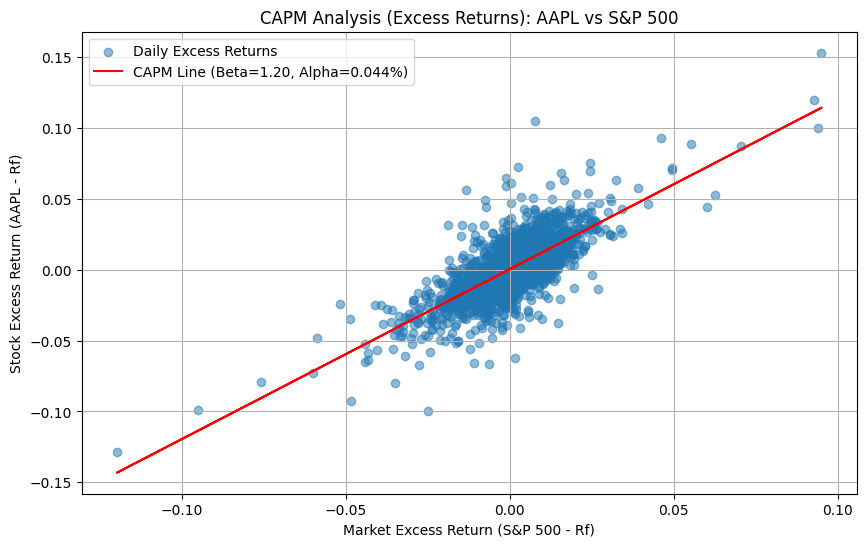

In [ ]:
# 6. Extract results
alpha = model.params.iloc[0]  # Daily excess return (alpha)
beta = model.params.iloc[1]   # Market sensitivity (beta)

print(f"--- Standard CAPM Analysis Results ---")
print(f"Beta: {beta:.4f}")
print(f"Daily Alpha: {alpha * 100:.4f}%")
# Annualize the pure excess return, excluding the risk-free rate
# The "alpha" here is the intercept from the daily excess return regression
# — it represents the average daily excess return that is earned each trading day (on top of market and risk-free rate).
# The annualization formula ((1 + alpha)**252 - 1) assumes this excess return compounds each day over 252 trading days.
# This is why we use exponentiation and not simple multiplication: in finance, returns typically compound, 
# so annualized return = (1 + daily alpha) ** 252 - 1.
# When alpha is very small, exponentiation and simple multiplication (alpha * 252) give similar results, but compounding is more accurate.

# Note: Interpreting regression alpha as a fixed daily rate and compounding it over an entire year is a strong assumption.
# In practice, it is safer to evaluate statistical significance (e.g. t-test), trading costs, frequency, and possible non-stationarity before relying on these annualized results.
print(f"Annualized Alpha: {((1 + alpha)**252 - 1) * 100:.4f}%")
print(f"R-squared: {model.rsquared:.4f}")

# 7. Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.5, label='Daily Excess Returns')
plt.plot(X, beta * X + alpha, color='red',
         label=f'CAPM Line (Beta={beta:.2f}, Alpha={alpha*100:.3f}%)')
plt.title('CAPM Analysis (Excess Returns): AAPL vs S&P 500')
plt.xlabel('Market Excess Return (S&P 500 - Rf)')
plt.ylabel('Stock Excess Return (AAPL - Rf)')
plt.legend()
plt.grid(True)
plt.show()

## Fama-French

In [55]:
import io
import re
import tempfile
import zipfile
import pandas as pd

from urllib.request import urlopen

def read_ken_french_csv_zip(
    name: str = "F-F_Research_Data_Factors_daily",
    start=None,
    end=None,
    *,
    table: int = 0,
    timeout: int = 60,
) -> pd.DataFrame:
    """
    Download a Ken French Data Library table from the FTP ZIP (…_CSV.zip), return the
    numeric block as a DataFrame — same numbers as in the file (typically **percent**),
    no resampling and no `/ 100`.

    Default `name` is daily Fama–French 3 factors (`F-F_Research_Data_Factors_daily`).
    Other examples: `F-F_Research_Data_Factors` (monthly), `F-F_Research_Data_5_Factors_2x3_daily`, etc.

    `table` selects which large CSV block to use when the ZIP contains more than one (0 = first).
    """
    base = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
    url = f"{base}{name}_CSV.zip"
    raw = urlopen(url, timeout=timeout).read()
    with tempfile.TemporaryFile() as tmpf:
        tmpf.write(raw)
        tmpf.seek(0)
        with zipfile.ZipFile(tmpf, "r") as zf:
            text = zf.open(zf.namelist()[0]).read().decode("utf-8", "ignore")

    blocks = [c for c in text.split("\r\n\r\n") if len(c) >= 800]
    src = blocks[table]
    m = re.search(r"^\s*,", src, re.MULTILINE)
    pos = 0 if m is None else m.start()
    df = pd.read_csv(io.StringIO("Date" + src[pos:]), index_col=0)

    ix = pd.Index(df.index).astype(int)
    lo = int(ix.min())
    if lo >= 1_000_000:
        df.index = pd.to_datetime(ix.astype(str), format="%Y%m%d")
    elif lo > 190_000:
        df.index = pd.to_datetime(ix.astype(str), format="%Y%m").to_period("M")
    else:
        df.index = pd.to_datetime(ix.astype(str), format="%Y").to_period("Y")

    return df.sort_index().truncate(before=start, after=end)


# Example: raw daily factors (percent); divide by 100 if you want decimals like yfinance returns.
# ff = read_ken_french_csv_zip("F-F_Research_Data_Factors_daily", start="2015-01-01")

# 1. Get Fama-French data
start_date = '2015-01-01'
ff = read_ken_french_csv_zip("F-F_Research_Data_Factors", start=start_date)
ff_factors = ff / 100

# 2. Get stock data (Adj Close 권장: 배당/분할 반영)
stock_data = yf.download('AAPL', start=start_date, interval='1mo')['Close']
stock_returns = stock_data.pct_change().dropna()
stock_returns.index = stock_returns.index.to_period('M')

[*********************100%***********************]  1 of 1 completed


In [59]:
ff_factors.head(2)

,Mkt-RF,SMB,HML,RF
Date,,,,
2015-01,-0.0310,-0.0059,-0.0345,0.0
2015-02,0.0613,0.0061,-0.0179,0.0


In [60]:
stock_returns.head(2)

Ticker,AAPL
Date,
2015-02,0.096449
2015-03,-0.027549


In [72]:
# Merge two returns data
data = pd.concat([stock_returns, ff_factors], axis=1).dropna()
data.columns = ['AAPL_Ret', 'Mkt_RF', 'SMB', 'HML', 'RF']

# Calculate excess returns
data['Ex_Ret'] = data["AAPL_Ret"] - data['RF']

In [ ]:
# Independent variables (X): Market premium, SMB, HML (+ constant term)
X = data[['Mkt_RF', 'SMB', 'HML']]
X = sm.add_constant(X)  # Add intercept (Alpha)

# Dependent variable (y): Stock excess returns
y = data['Ex_Ret']

# Fit OLS model
model = sm.OLS(y, X).fit()

# Print results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Ex_Ret   R-squared:                       0.479
Model:                            OLS   Adj. R-squared:                  0.467
Method:                 Least Squares   F-statistic:                     39.60
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           3.28e-18
Time:                        17:19:46   Log-Likelihood:                 194.63
No. Observations:                 133   AIC:                            -381.3
Df Residuals:                     129   BIC:                            -369.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0068      0.005      1.328      0.1

In [75]:
betas = model.params
intercept = betas['const']      # Monthly Alpha
beta_mkt = betas['Mkt_RF']      # Market Beta
beta_smb = betas['SMB']         # Size Beta
beta_hml = betas['HML']         # Value Beta

# 2. Calculate annualized alpha (Monthly Alpha -> Annualized Alpha)
# Formula: (1 + monthly_alpha)^12 - 1
annualized_alpha = (1 + intercept) ** 12 - 1

# 3. Print results
print("=" * 40)
print(f"   [ AAPL Fama-French 3-Factor Results ]")
print("=" * 40)
print(f"Market Beta (β) : {beta_mkt:>10.4f}")
print(f"Size Beta (s)   : {beta_smb:>10.4f}")
print(f"Value Beta (h)  : {beta_hml:>10.4f}")
print("-" * 40)
print(f"Monthly Alpha   : {intercept*100:.4f}%")
print(f"Annualized Alpha: {annualized_alpha*100:.2f}%")
print("=" * 40)

   [ AAPL Fama-French 3-Factor Results ]
Market Beta (β) :     1.1707
Size Beta (s)   :    -0.1508
Value Beta (h)  :    -0.4502
----------------------------------------
Monthly Alpha   : 0.6771%
Annualized Alpha: 8.44%


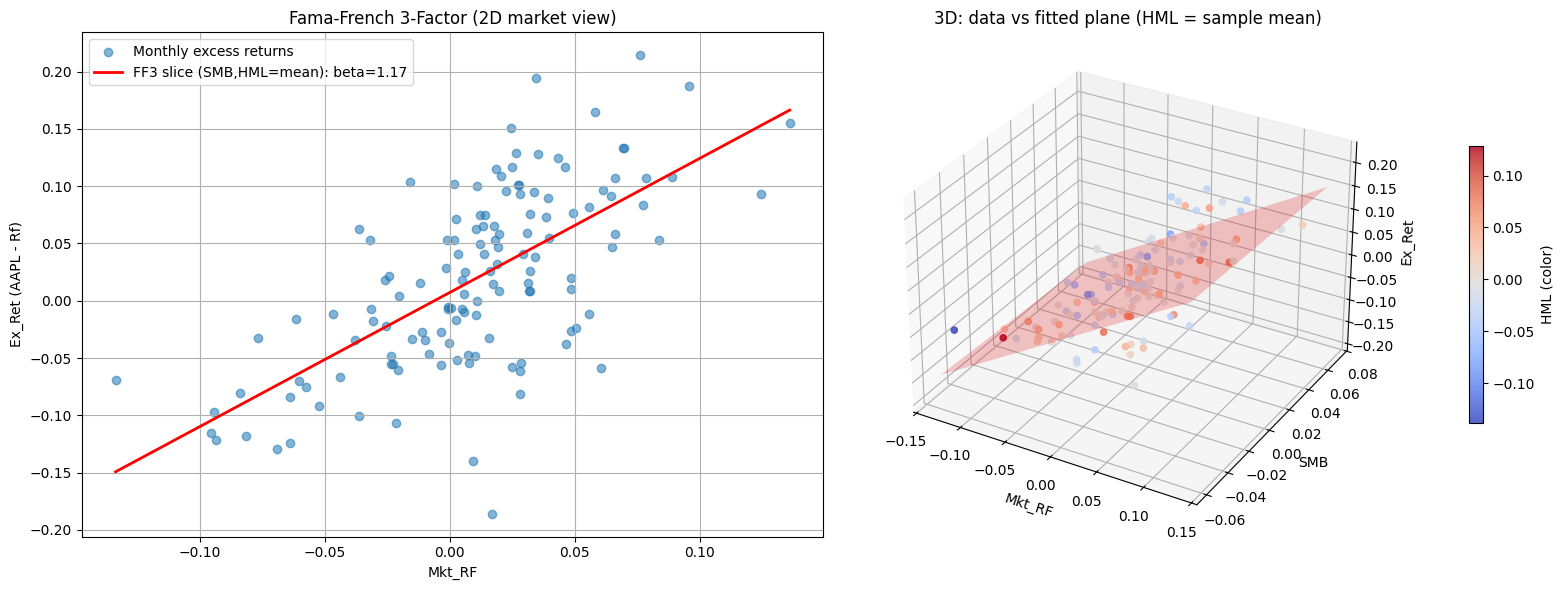

In [78]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 - registers 3d projection

# --- 2D slice (CAPM-style): Mkt_RF vs excess return, SMB & HML at sample means ---
mkt_excess = data["Mkt_RF"]
stock_excess = data["Ex_Ret"]
smb_bar = data["SMB"].mean()
hml_bar = data["HML"].mean()

x0, x1 = float(mkt_excess.min()), float(mkt_excess.max())
y0 = intercept + beta_mkt * x0 + beta_smb * smb_bar + beta_hml * hml_bar
y1 = intercept + beta_mkt * x1 + beta_smb * smb_bar + beta_hml * hml_bar

fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(mkt_excess, stock_excess, alpha=0.55, label="Monthly excess returns")
ax1.plot([x0, x1], [y0, y1], color="red", linewidth=2,
         label=f"FF3 slice (SMB,HML=mean): beta={beta_mkt:.2f}")
ax1.set_title("Fama-French 3-Factor (2D market view)")
ax1.set_xlabel("Mkt_RF")
ax1.set_ylabel("Ex_Ret (AAPL - Rf)")
ax1.legend()
ax1.grid(True)

# --- 3D: Mkt_RF, SMB on floor, Ex_Ret on vertical; plane = fit with HML fixed at mean ---
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
sc = ax2.scatter(
    data["Mkt_RF"], data["SMB"], data["Ex_Ret"],
    c=data["HML"], cmap="coolwarm", alpha=0.85, depthshade=True,
)
mrf = np.linspace(data["Mkt_RF"].min(), data["Mkt_RF"].max(), 35)
smb = np.linspace(data["SMB"].min(), data["SMB"].max(), 35)
M, S = np.meshgrid(mrf, smb)
Z = intercept + beta_mkt * M + beta_smb * S + beta_hml * hml_bar
ax2.plot_surface(M, S, Z, color="red", alpha=0.22, linewidth=0, antialiased=True)
ax2.set_xlabel("Mkt_RF")
ax2.set_ylabel("SMB")
ax2.set_zlabel("Ex_Ret")
ax2.set_title("3D: data vs fitted plane (HML = sample mean)")
cb = fig.colorbar(sc, ax=ax2, shrink=0.55, pad=0.12)
cb.set_label("HML (color)")

plt.tight_layout()
plt.show()
